# Fine-Tuning ResNet-18

This notebook fine-tunes a pretrained ResNet-18 on the DeepWeeds dataset. The lower layers remain frozen, while the upper `layer4` block and final classification layer are trained.

In [1]:
import os
import copy
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

BASE_DIR = os.path.expanduser("~/Developer/curtin/NNSML/datasets/DeepWeeds")
IMAGES_DIR = os.path.join(BASE_DIR, "images")
LABELS_DIR = os.path.join(BASE_DIR, "labels")

TRAIN_CSV = os.path.join(LABELS_DIR, "train_subset0.csv")
VAL_CSV = os.path.join(LABELS_DIR, "val_subset0.csv")
TEST_CSV = os.path.join(LABELS_DIR, "test_subset0.csv")

RESULTS_DIR = "../results"
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
TABLES_DIR = os.path.join(RESULTS_DIR, "tables")
CHECKPOINTS_DIR = os.path.join(RESULTS_DIR, "checkpoints")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

CLASS_NAMES = [
    "Chinee Apple",
    "Lantana",
    "Parkinsonia",
    "Parthenium",
    "Prickly Acacia",
    "Rubber Vine",
    "Siam Weed",
    "Snake Weed",
    "Negatives",
]

NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

Using device: cpu


In [5]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

for split_df in [train_df, val_df, test_df]:
    split_df["image_path"] = split_df["Filename"].apply(lambda x: os.path.join(IMAGES_DIR, x))
    split_df["label"] = split_df["Label"].astype(int)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)


Train: (10501, 4)
Val: (3501, 4)
Test: (3507, 4)


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [7]:
class DeepWeedsDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
train_dataset = DeepWeedsDataset(train_df, transform=train_transform)
val_dataset = DeepWeedsDataset(val_df, transform=eval_transform)
test_dataset = DeepWeedsDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 329
Val batches: 110
Test batches: 110


In [9]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:10].tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Sample labels: [4, 8, 8, 8, 8, 7, 5, 4, 7, 8]


In [10]:
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)

# Unfreeze layer4 and fc
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(DEVICE)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
trainable_param_names = []
for name, param in model.named_parameters():
    if param.requires_grad:
        trainable_param_names.append(name)

print("Trainable layers:")
for name in trainable_param_names:
    print(name)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"\nTrainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

Trainable layers:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias

Trainable parameters: 8,398,345
Total parameters: 11,181,129


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return epoch_loss, epoch_acc, precision, recall, f1

In [14]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return epoch_loss, epoch_acc, precision, recall, f1, all_labels, all_preds

In [15]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_f1 = -1.0

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), os.path.join(CHECKPOINTS_DIR, "resnet18_finetuned_best.pth"))

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}"
    )

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed/60:.2f} minutes")

Epoch [1/10] | Train Loss: 0.7522, Train Acc: 0.7416, Train F1: 0.6526 | Val Loss: 0.5024, Val Acc: 0.8286, Val F1: 0.7573
Epoch [2/10] | Train Loss: 0.4187, Train Acc: 0.8587, Train F1: 0.8138 | Val Loss: 0.3633, Val Acc: 0.8726, Val F1: 0.8299
Epoch [3/10] | Train Loss: 0.3419, Train Acc: 0.8795, Train F1: 0.8438 | Val Loss: 0.3488, Val Acc: 0.8857, Val F1: 0.8472
Epoch [4/10] | Train Loss: 0.2835, Train Acc: 0.9012, Train F1: 0.8726 | Val Loss: 0.3446, Val Acc: 0.8857, Val F1: 0.8449
Epoch [5/10] | Train Loss: 0.2450, Train Acc: 0.9167, Train F1: 0.8904 | Val Loss: 0.3086, Val Acc: 0.8972, Val F1: 0.8606
Epoch [6/10] | Train Loss: 0.2079, Train Acc: 0.9271, Train F1: 0.9044 | Val Loss: 0.2861, Val Acc: 0.9069, Val F1: 0.8768
Epoch [7/10] | Train Loss: 0.1926, Train Acc: 0.9332, Train F1: 0.9151 | Val Loss: 0.2944, Val Acc: 0.9040, Val F1: 0.8690
Epoch [8/10] | Train Loss: 0.1716, Train Acc: 0.9424, Train F1: 0.9261 | Val Loss: 0.2772, Val Acc: 0.9103, Val F1: 0.8797
Epoch [9/10] | T

In [16]:
model.load_state_dict(best_model_wts)
print("Loaded best model based on validation macro F1.")

Loaded best model based on validation macro F1.


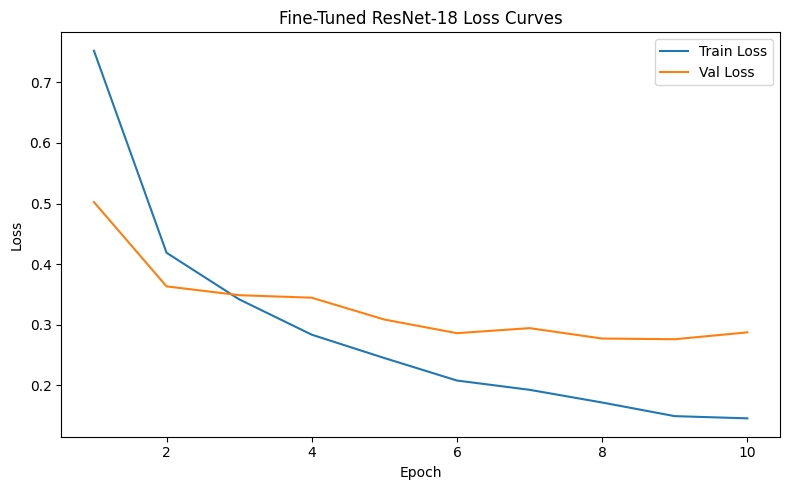

In [17]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuned ResNet-18 Loss Curves")
plt.legend()
plt.tight_layout()
plt.show()

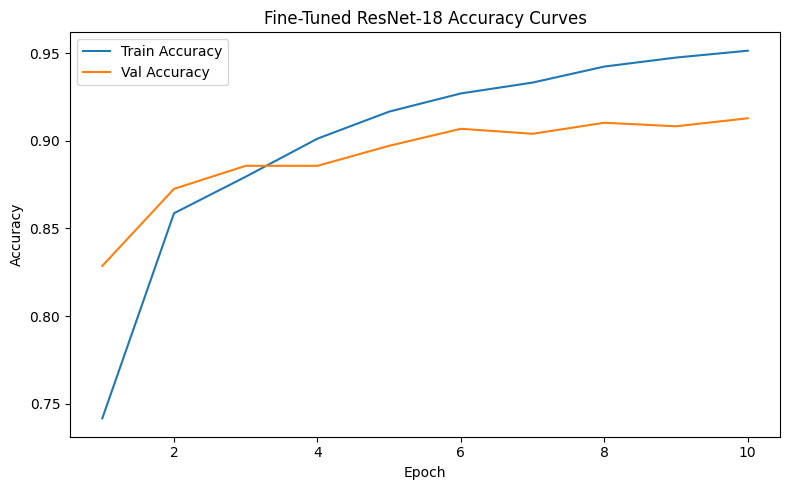

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuned ResNet-18 Accuracy Curves")
plt.legend()
plt.tight_layout()
plt.show()

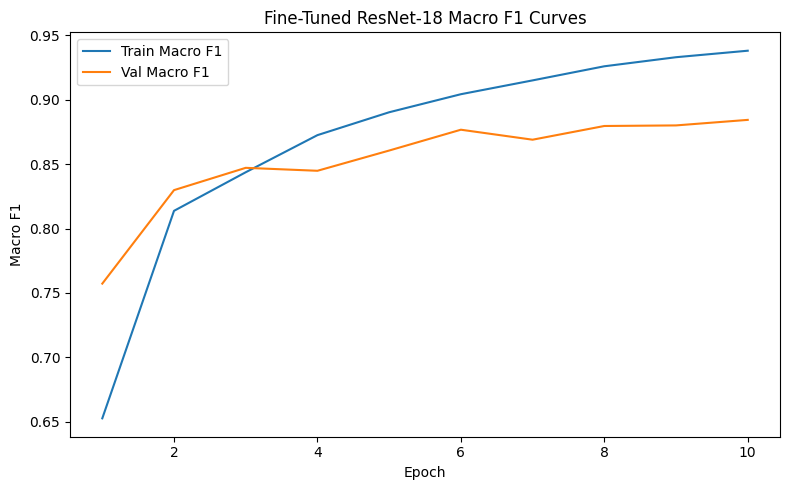

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_f1"], label="Train Macro F1")
plt.plot(epochs, history["val_f1"], label="Val Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Fine-Tuned ResNet-18 Macro F1 Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
test_loss, test_acc, test_prec, test_rec, test_f1, y_true, y_pred = evaluate(
    model, test_loader, criterion, DEVICE
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro Precision: {test_prec:.4f}")
print(f"Test Macro Recall: {test_rec:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")

Test Loss: 0.2911
Test Accuracy: 0.9096
Test Macro Precision: 0.8908
Test Macro Recall: 0.8692
Test Macro F1: 0.8746


In [21]:
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
Chinee Apple,0.687943,0.858407,0.763780,226.000000
Lantana,0.859031,0.915493,0.886364,213.000000
Parkinsonia,0.914027,0.975845,0.943925,207.000000
Parthenium,0.940541,0.848780,0.892308,205.000000
Prickly Acacia,0.913462,0.892019,0.902613,213.000000
Rubber Vine,0.896907,0.861386,0.878788,202.000000
Siam Weed,0.937799,0.911628,0.924528,215.000000
Snake Weed,0.924812,0.602941,0.729970,204.000000
Negatives,0.942641,0.956092,0.949319,1822.000000
accuracy,0.909609,0.909609,0.909609,0.909609


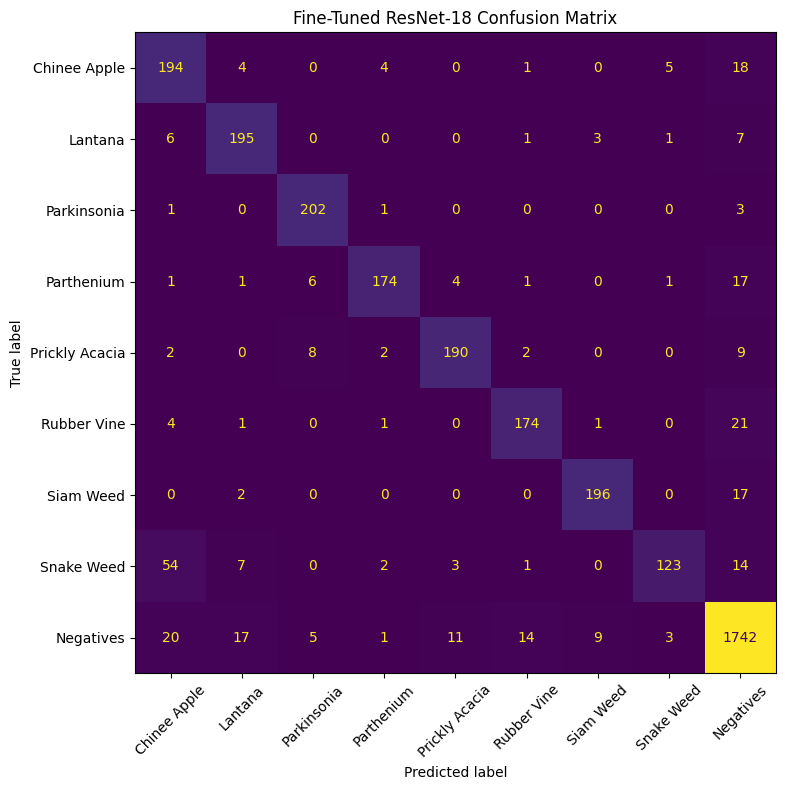

In [22]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Fine-Tuned ResNet-18 Confusion Matrix")
plt.tight_layout()
plt.show()

In [23]:
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(TABLES_DIR, "resnet18_finetuned_history.csv"), index=False)

report_df.to_csv(os.path.join(TABLES_DIR, "resnet18_finetuned_classification_report.csv"))

np.savetxt(
    os.path.join(TABLES_DIR, "resnet18_finetuned_confusion_matrix.csv"),
    cm,
    delimiter=",",
    fmt="%d"
)

summary_df = pd.DataFrame([{
    "model": "ResNet18_FineTuned",
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_val_f1": best_val_f1,
    "test_loss": test_loss,
    "test_accuracy": test_acc,
    "test_macro_precision": test_prec,
    "test_macro_recall": test_rec,
    "test_macro_f1": test_f1,
    "training_time_minutes": elapsed / 60,
}])

summary_df.to_csv(os.path.join(TABLES_DIR, "resnet18_finetuned_summary.csv"), index=False)

print("Saved fine-tuned ResNet-18 outputs.")

Saved fine-tuned ResNet-18 outputs.


In [24]:
baseline_path = os.path.join(TABLES_DIR, "baseline_cnn_summary.csv")
frozen_path = os.path.join(TABLES_DIR, "resnet18_frozen_summary.csv")

frames = []

if os.path.exists(baseline_path):
    frames.append(pd.read_csv(baseline_path))

if os.path.exists(frozen_path):
    frames.append(pd.read_csv(frozen_path))

frames.append(summary_df)

comparison_df = pd.concat(frames, ignore_index=True)
comparison_df

,model,epochs,batch_size,learning_rate,weight_decay,best_val_f1,test_loss,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,training_time_minutes
0,BaselineCNN,15,32,0.0010,0.0001,0.215444,1.115906,0.572284,0.575569,0.235289,0.218140,54.352119
1,ResNet18_Frozen,10,32,0.0010,0.0001,0.697798,0.691668,0.764471,0.744464,0.639449,0.675704,45.478012
2,ResNet18_FineTuned,10,32,0.0001,0.0001,0.884441,0.291065,0.909609,0.890796,0.869177,0.874622,49.523126


## Fine-Tuned ResNet-18 Observations

- Fine-tuning substantially improved performance beyond the frozen ResNet-18 model.
- Test accuracy increased to 0.9096 and test macro F1 increased to 0.8746, making this the best-performing model so far.
- The training and validation curves indicate stable learning, with only a modest train-validation gap by the final epochs.
- Class-level performance improved across almost all weed classes, and the confusion with the Negatives class decreased further.
- The strongest class-balanced gains were observed in classes that were weak in the baseline model.
- Snake Weed remained the most difficult class, but its performance was still much better than in the frozen and baseline settings.
- Overall, fine-tuning the upper ResNet layers was clearly worthwhile and produced the strongest results in this project.